# Training algorithm for O2 gapfill
    - Updated for full depth, coverage up to 2025
    - Needs to enter a 6 digit input parameter as follows : 
    - First digit = Algorithm type (1=RF, 2=NN)
    - Second digit = Data Source (1=Ship only, 2=Ship+Argo)
    - Third digit = Ocean basin (1=Atlantic, 2=Pacific, 3=Indian, 4=Southern, 5=Arctic)
    - Fourth digit = T/S data source (1=EN4, 2=ORAS4, 3=SODA3.4.2, 4=EN4/C14)
    - Fifth digit = predictor variable set (1=[T,S,p,lon,lat,year,month], 2=[T,S,p,lon,lat,year,cos/sin_month], 3=[T,S,p,lon,lat,year,cos/sin_month,sigma-theta], 4=[T,S,p,lon,lat,year,cos/sin_month,sigma-theta,N2], 5=[T,S,p,lon,lat,cos/sin_month], 6=[T,S,p,lon,lat,GlobalSST,cos/sin_month])
    - Sixth digit = hyperparameter set (1=default, 2=preset hyperparameters, 4=DKCV)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import sklearn as skl
import gsw
import cartopy.crs as ccrs
from scipy.interpolate import interp1d
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
# version information
ver = '1.3.1.4.6.4'
# The version information will determine which basin / algorithm will be used to calculate the O2 maps. 
o2_cutoff = 600 # this is an arbitrary defined cut-off value to remove very large O2 input data from Argo
#
os.system('echo $USER > userid')
usrid=np.genfromtxt('userid',dtype='<U16')
os.system('rm userid')
#
dirn=f'/glade/derecho/scratch/{usrid}/ML4O2/input_202602'
com=f'mkdir -p {dirn}'
os.system(com)
#
# combine OSD, CTD and PFL equally
eqave=0
# eqave=0 means the o2 value is weighted by profile count
argo_offset = 1.69

### display selection

In [3]:
selection = ver.split('.')
basin = ['Atlantic','Pacific','Indian','Southern','Arctic']
#
if selection[0] == '1':
    print('Random Forst algorithm will be used.')
    alg = 'RF'
elif selection[0] == '2':
    print('Neural Network algorithm will be used.')
    alg = 'NN'
else:
    print('error - incorrect algorithm type')
#
if selection[1] == '1':
    print('Ship-based O2 data will be used. ')
elif selection[1] == '2':
    print('Ship-based and Argo-O2 data will be used. ')
elif selection[1] == '3':
    print('Ship-based and modified Argo-O2 data will be used. ')
else:
    print('error - incorrect input data type')
#
if selection[2] == '1':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '2':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '3':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '4':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
elif selection[2] == '5':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
else:
    print('error - incorrect O2 data type')
#
if selection[3] == '1':
    print('EN4 dataset will be used for T/S input. ')
    endyear=2021
elif selection[3] == '2':
    print('ORAS4 dataset will be used for T/S input. ')
    endyear=2018
elif selection[3] == '3':
    print('SODA3.4.2 dataset will be used for T/S input. ')
elif selection[3] == '4':
    print('EN4 (C14) dataset will be used for T/S input. ')
    endyear=2024
else:
    print('error - incorrect T/S data type')
#
if selection[4] == '1':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, month')
elif selection[4] == '2':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)')
elif selection[4] == '3':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma0')
elif selection[4] == '4':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma0, N2')
#NEW
elif selection[4] == '5':
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '6':
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
#NEW
else:
    print('error - incorrect predictor variable type')
#
if selection[5] == '1':
    print('Hyperparameter set is optimized via K-fold CV')
elif selection[5] == '2':
    print('A pre-set hyperparameter set is used')
elif selection[5] == '4':
    print('New train/test splid and K-fold cross validation')
else:
    print('error - incorrect hyperparameter type')

Random Forst algorithm will be used.
Ship-based and modified Argo-O2 data will be used. 
Atlantic Ocean will be mapped
EN4 (C14) dataset will be used for T/S input. 
Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)
New train/test splid and K-fold cross validation


In [4]:
# Define the input and output folders
#
os.system('echo $USER > userid')
usrid=np.genfromtxt('userid',dtype='<U8')
os.system('rm userid')
diro = '/glade/derecho/scratch/'+str(usrid)+'/ML4O2_temp/'
if selection[3]=='1':
    dirf = '/glade/campaign/univ/ugit0034/EN4/L09_20x180x360/'
    dbase='EN4_TSN2_L09_180x360_'
    roll180=0
elif selection[3]=='2':
    dirf = '/glade/campaign/univ/ugit0034/ORAS4/TSN2/'
    dbase='ORAS4_TSN2_'
    roll180=1
elif selection[3]=='4':
    dirf = '/glade/campaign/univ/ugit0034/EN4/C14/'
    dbase='EN4_C14_180x360_'
    roll180=0
# This is where the source data is ---
#dirin = '/glade/campaign/univ/ugit0034/WOD_O2_2022-25/'
dirin = '/glade/campaign/univ/ugit0034/Zhankun/'
#
fosd='_1x1bin_osd_1965-2025'
fctd='_1x1bin_ctd_1987-2025'
fpfl='_1x1bin_pfl_2005-2025'
var=['Oxygen']
os.system('mkdir -p '+diro)
os.system('mkdir -p '+diro+'temp')

0

### Preprocessing the data
- New in 2025
- Depth is extended to 5500m
- Training data is including Global mean SST rather than year

In [5]:
# obtain vertical grid
ds=xr.open_dataset(dirin+var[0]+fosd+'.nc')
Z=ds.depth.to_numpy()
Nz=np.size(Z)
print(Nz,Z)

102 [0.00e+00 5.00e+00 1.00e+01 1.50e+01 2.00e+01 2.50e+01 3.00e+01 3.50e+01
 4.00e+01 4.50e+01 5.00e+01 5.50e+01 6.00e+01 6.50e+01 7.00e+01 7.50e+01
 8.00e+01 8.50e+01 9.00e+01 9.50e+01 1.00e+02 1.25e+02 1.50e+02 1.75e+02
 2.00e+02 2.25e+02 2.50e+02 2.75e+02 3.00e+02 3.25e+02 3.50e+02 3.75e+02
 4.00e+02 4.25e+02 4.50e+02 4.75e+02 5.00e+02 5.50e+02 6.00e+02 6.50e+02
 7.00e+02 7.50e+02 8.00e+02 8.50e+02 9.00e+02 9.50e+02 1.00e+03 1.05e+03
 1.10e+03 1.15e+03 1.20e+03 1.25e+03 1.30e+03 1.35e+03 1.40e+03 1.45e+03
 1.50e+03 1.55e+03 1.60e+03 1.65e+03 1.70e+03 1.75e+03 1.80e+03 1.85e+03
 1.90e+03 1.95e+03 2.00e+03 2.10e+03 2.20e+03 2.30e+03 2.40e+03 2.50e+03
 2.60e+03 2.70e+03 2.80e+03 2.90e+03 3.00e+03 3.10e+03 3.20e+03 3.30e+03
 3.40e+03 3.50e+03 3.60e+03 3.70e+03 3.80e+03 3.90e+03 4.00e+03 4.10e+03
 4.20e+03 4.30e+03 4.40e+03 4.50e+03 4.60e+03 4.70e+03 4.80e+03 4.90e+03
 5.00e+03 5.10e+03 5.20e+03 5.30e+03 5.40e+03 5.50e+03]


In [6]:
# select analysis period
endyear=2025
# do not change the start year from 1965 (this is when Carpenter 1965 established modern Winkler method)
yrs=np.arange(1965,endyear+1,1)
yrs

array([1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024, 2025])

Atlantic Ocean will be mapped


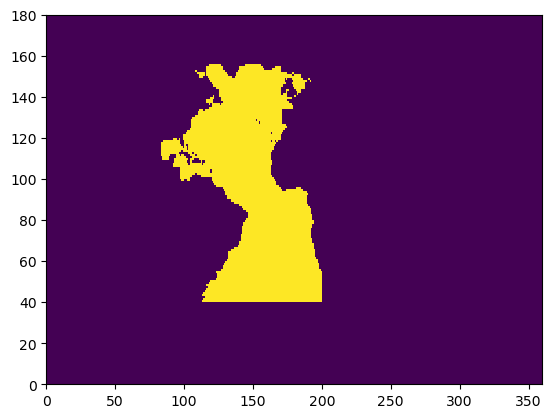

In [7]:
# basin mask
dsm=xr.open_dataset('/glade/campaign/univ/ugit0034/wod18/basin_mask_01.nc')
ma = dsm.basin_mask.isel(depth=0).to_numpy()
#
if selection[2] == '1':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==1,1,0)
elif selection[2] == '2':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==2,1,0)
elif selection[2] == '3':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where((ma==3)|(ma==56),1,0)
elif selection[2] == '4':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==10,1,0)
elif selection[2] == '5':
    print(basin[int(selection[2])-1]+' Ocean will be mapped')
    mask = np.where(ma==11,1,0)
else:
    print('error - incorrect O2 data type')
#
plt.pcolormesh(mask)

In [8]:
# NEW in 2025
# Obtain O2 data from observational dataset
#
#  Argo O2 bias correction can happen here!
#
Nyr=np.size(yrs)
Nt=Nyr*12
mon=["%.2d" % i for i in np.arange(1,13,1)]
#
o2=np.zeros((Nt,Nz,180,360))
#
ds1=xr.open_dataset(dirin+var[0]+fosd+'.nc')
ds2=xr.open_dataset(dirin+var[0]+fctd+'.nc')
ds3=xr.open_dataset(dirin+var[0]+fpfl+'.nc')
#
for year in yrs:
    ytmp=year%10
    if ytmp==0:
        print(str(year))
    tr=12*(year-1965)
    timeind0=(year-2005)*12
    if (year<1987):#|(selection[1]=='1'):
        o2[tr:(tr+12),:,:,:]=ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
    elif (year<2005)|(selection[1]=='1'):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc)/(cntb+cntc)
    elif (selection[1]=='2'):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2p = ds3.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntp= ds3.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        o2p=np.where(np.isnan(o2p),0,o2p)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
            cntp[cntp>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc+o2p*cntp)/(cntb+cntc+cntp)
    elif (selection[1]=='3'):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2p = ds3.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()+argo_offset
        cntp= ds3.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).to_numpy()
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        o2p=np.where(np.isnan(o2p),0,o2p)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
            cntp[cntp>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc+o2p*cntp)/(cntb+cntc+cntp)
    # result quick check
    #tmp=o2[tr:(tr+12),:,:,:].flatten()
    #print(year,np.nanmax(tmp),np.nanmin(tmp))

1970
1980
1990
2000
2010
2020


In [9]:
#
# Obtain T/S data from observational gridded dataset
#
t=np.zeros((Nt,Nz,180,360))*np.nan
s=np.zeros((Nt,Nz,180,360))*np.nan
#
for year in yrs:
    ytmp=year%10
    if ytmp==0:
        print(str(year))
    tr=12*(year-1965)
    if year <= 2024:
        Nmon=12
    else:
        Nmon=12
    for mn in range(Nmon):
        ds = xr.open_dataset(dirf+dbase+str(year)+mon[mn]+'.nc')
        print(dirf+dbase+str(year)+mon[mn]+'.nc')
        if roll180==1:
            ds.coords['lon'] = (ds.coords['lon'] + 180) % 360 - 180
            ds = ds.sortby(ds.lon)
        s[tr+mn,:,:,:]=ds.so.interp(depth=Z).to_numpy().squeeze()
        t[tr+mn,:,:,:]=ds.thetao.interp(depth=Z).to_numpy().squeeze()

/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196501.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196502.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196503.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196504.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196505.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196506.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196507.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196508.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196509.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196510.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196511.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196512.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196601.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196602.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN4_C14_180x360_196603.nc
/glade/campaign/univ/ugit0034/EN4/C14/EN

In [10]:
# get coordinates
x=ds.lon.to_numpy() 
# use alternative x coordinate: longitude - 20
xa0 = x - 20
xalt = np.where(xa0<0,xa0+360,xa0)
#
y=ds.lat.to_numpy()
xi=np.arange(0,360,1)
yi=np.arange(0,180,1)
xx,yy=np.meshgrid(xalt,y)
xxi,yyi=np.meshgrid(xi,yi)

In [11]:
# extract mask
mask2d=np.zeros((1,180,360))
mask2d[0,:,:] = dsm.basin_mask.sel(depth=0)
mask2d = np.where(mask2d==56,3,mask2d)
mask3d = np.tile(mask2d,[np.size(Z),1,1])
mask= dsm.basin_mask.sel(depth=Z)
#
mask=np.where(mask==0,0,mask3d)
#print(np.shape(mask))
#np.unique(mask2d)

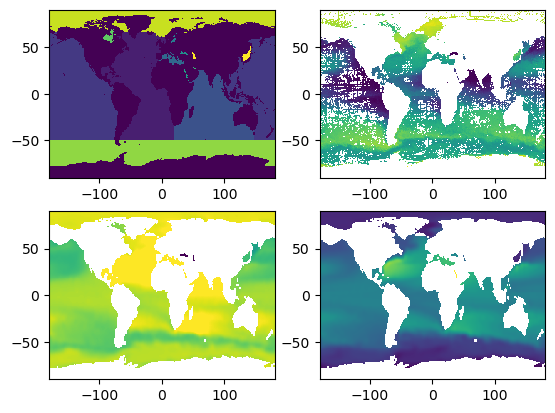

In [12]:
# take a look at the data
fig,ax=plt.subplots(2,2)
# select 500m for plotting
kind=[idx for idx,elem in enumerate(Z) if elem==500]
#
ax[0,0].pcolormesh(x,y,mask[8,:,:],vmin=0,vmax=12,label='basin_mask')
ax[0,1].pcolormesh(x,y,np.nanmean(o2[:,kind[0],:,:],axis=0))
ax[1,0].pcolormesh(x,y,np.nanmean(s[:,kind[0],:,:],axis=0),vmin=32,vmax=35)
ax[1,1].pcolormesh(x,y,np.nanmean(t[:,kind[0],:,:],axis=0))

In [13]:
# prepare basin wise array

In [14]:
# prepare depth lat lon time data
xx1  = np.tile(xx,[Nz,1,1])
yy1  = np.tile(yy,[Nz,1,1])
xxSO = (yy+90)*np.cos(np.deg2rad(xx))
yySO = (yy+90)*np.sin(np.deg2rad(xx))
xxAO = (-yy+90)*np.cos(np.deg2rad(xx))
yyAO = (-yy+90)*np.sin(np.deg2rad(xx))
#
xx1SO = np.tile(xxSO,[Nz,1,1])
yy1SO = np.tile(yySO,[Nz,1,1])
xx1AO = np.tile(xxAO,[Nz,1,1])
yy1AO = np.tile(yyAO,[Nz,1,1])
ztmp  = np.tile(Z,[180,360,1])
zz1   = np.transpose(ztmp,[2,0,1])

In [15]:
dsg=xr.open_dataset('NOAA_Global_SST.nc')
GMT=dsg.SST.sel(time=slice('1965-01','2025-12')).to_numpy()
print(Nt,GMT.size)

732 732


In [16]:
Nlev=102
print(Nlev,Nt)

102 732


In [18]:
# up to December 2025
Nt=732
#
bnames=['atlantic','pacific','indian','southern','arctic','mediterranean','baltic','black','red','persian','hudson','japan-east','caspian']
bindex=[1,2,3,10,11,4,5,6,7,8,9,12,53]
#
for bid in np.arange(1,14,1):
    dsa1=np.array([])
    dta1=np.array([])
    xx1s=np.array([])
    yy1s=np.array([])
    zz1s=np.array([])
    tt1s=np.array([])
    tc1s=np.array([])
    doa1s=np.array([])
    GMT1=np.array([])
    bname0=bnames[bid-1]
    #
    for n in range(Nt):
        t0 = n
        t1 = t0%12
        tt1 = np.ones((Nz,180,360))*t0
        tc1 = np.ones((Nz,180,360))*t1
        GMT0= np.ones((Nz,180,360))*GMT[n]
        #if t1==0:
        #    print(n/12+1965)
        o20=o2[n,:,:,:]
        theta0=t[n,:,:,:]
        s0=s[n,:,:,:]
        tmp = o20+theta0+s0
        #
        #print(bnames[bid-1])
        if bid==3:
            dd = np.where((mask==3)|(mask==56),tmp,np.nan)
        else:
            dd = np.where(mask==bindex[bid-1],tmp,np.nan)
        #
        dsa1=np.concatenate((dsa1,s0[np.isnan(dd)==False]))
        dta1=np.concatenate((dta1,theta0[np.isnan(dd)==False]))
        #
        if bid == 4:
            xx1s=np.concatenate((xx1s,xx1SO[np.isnan(dd)==False]))
        elif bid == 5:
            xx1s=np.concatenate((xx1s,xx1AO[np.isnan(dd)==False]))
        else:
            xx1s=np.concatenate((xx1s,xx1[np.isnan(dd)==False]))
        if bid == 4:
            yy1s=np.concatenate((yy1s,yy1SO[np.isnan(dd)==False]))
        elif bid == 5:
            yy1s=np.concatenate((yy1s,yy1AO[np.isnan(dd)==False]))
        else:
            yy1s=np.concatenate((yy1s,yy1[np.isnan(dd)==False]))
        #
        zz1s=np.concatenate((zz1s,zz1[np.isnan(dd)==False]))
        tt1s=np.concatenate((tt1s,tt1[np.isnan(dd)==False]))
        GMT1=np.concatenate((GMT1,GMT0[np.isnan(dd)==False]))
        tc1s=np.concatenate((tc1s,tc1[np.isnan(dd)==False]))
        doa1s=np.concatenate((doa1s,o20[np.isnan(dd)==False]))
        #
    #
    Nsample = np.size(doa1s)
    print(bname0,Nsample)    
    np.save(f'{dirn}/o20_{bname0}_1x1_{Nlev}lev.npy',doa1s)
    np.save(f'{dirn}/month0_{bname0}_1x1_{Nlev}lev.npy',tc1s)
    np.save(f'{dirn}/time0_{bname0}_1x1_{Nlev}lev.npy',tt1s)
    np.save(f'{dirn}/depth0_{bname0}_1x1_{Nlev}lev.npy',zz1s)
    np.save(f'{dirn}/lon0_{bname0}_1x1_{Nlev}lev.npy',xx1s)
    np.save(f'{dirn}/lat0_{bname0}_1x1_{Nlev}lev.npy',yy1s)
    np.save(f'{dirn}/t0_{bname0}_1x1_{Nlev}lev.npy',dta1)
    np.save(f'{dirn}/s0_{bname0}_1x1_{Nlev}lev.npy',dsa1)
    np.save(f'{dirn}/GMT0_{bname0}_1x1_{Nlev}lev.npy',GMT1)

atlantic 4443293
pacific 5840187
indian 1729138
southern 2012060
arctic 1077886
mediterranean 326149
baltic 154120
black 54234
red 1110
persian 471
hudson 964
japan-east 218297
caspian 19667
